IMPORT LIBRARIES

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

LOAD DATASET

In [35]:
df = pd.read_csv("adult.csv")

print("First 10 rows:\n", df.head(10))
print("Shape:", df.shape)
print("Features:", df.columns.tolist())


First 10 rows:
    age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-managerial

DATA CLEANING

In [36]:
df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)


ENCODED TARGET VARIABLE

In [37]:
df['income'] = df['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

ENCODED CATEGORICAL FEATURES

In [38]:
df_encoded = pd.get_dummies(df, drop_first=True)

DEFINE FEATURES & TARGET

In [39]:
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

K FOLD CROSS VALIDATION

In [40]:
model = DecisionTreeClassifier(random_state=42)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    model, X, y, cv=kfold,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print("\n===== K-FOLD RESULTS =====")
print("Mean Accuracy:", cv_results['test_accuracy'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())
print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Std Accuracy:", cv_results['test_accuracy'].std())


===== K-FOLD RESULTS =====
Mean Accuracy: 0.8111529492301625
Mean Precision: 0.6180188440183059
Mean Recall: 0.6316025196580792
Mean F1 Score: 0.6246545801242249
Std Accuracy: 0.007397826359652453


TRAIN-TEST SPLIT

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

TREE INFO

In [42]:
print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())


Tree Depth: 49
Number of Leaves: 3136


PREDICTIONS

In [43]:
y_pred = model.predict(X_test)

EVALUATION METRICS

In [44]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== TEST SET METRICS =====")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


===== TEST SET METRICS =====
Accuracy: 0.8098132390319372
Precision: 0.6219201359388276
Recall: 0.6379084967320261
F1 Score: 0.6298128629812862


ROC CURVE & AUC

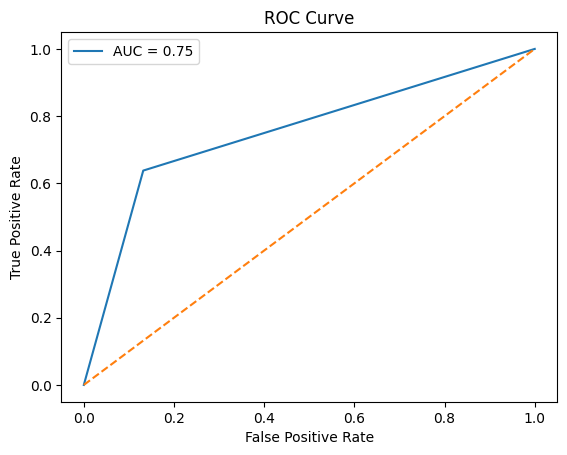

AUC Score: 0.7530673665182192


In [45]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)